In [7]:
#importing the libraries needed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from collections import Counter

In [22]:
# We create 5 classes with speccific weights to show extreme imbalance
X, y = make_classification(
    n_samples=2000,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    n_classes=5,
    weights=[0.70, 0.15, 0.10, 0.03, 0.02],
    random_state=42
)
                           

Original data set shape: Counter({np.int64(0): 3485, np.int64(1): 748, np.int64(2): 503, np.int64(3): 156, np.int64(4): 108})


Text(0, 0.5, 'Number of samples')

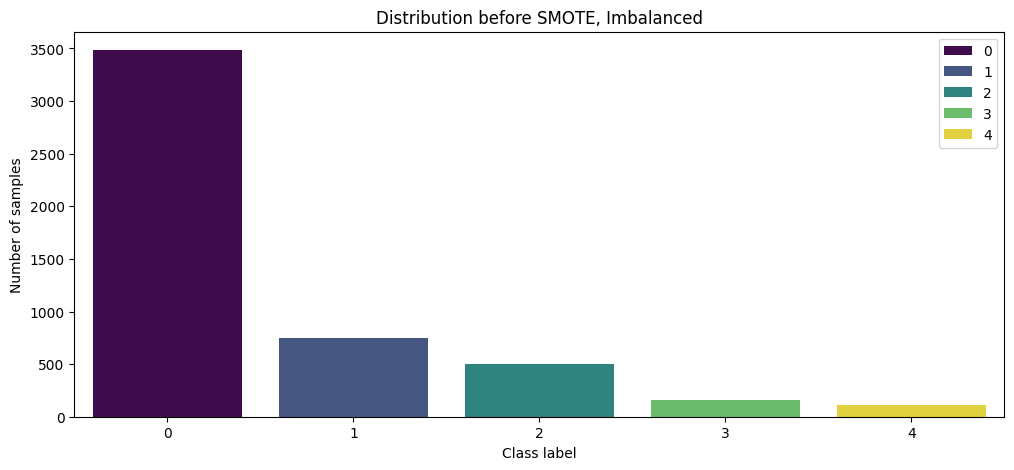

In [21]:
# checking distribution and bar chart of class count
print(f"Original data set shape: {Counter(y)}")

plt.figure(figsize=(12, 5))
plt.subplot(1,1,1)
sns.countplot(x=y,hue =y, palette='viridis')
plt.title('Distribution before SMOTE, Imbalanced')
plt.xlabel('Class label')
plt.ylabel('Number of samples')

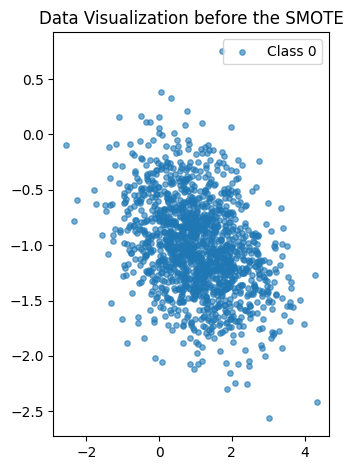

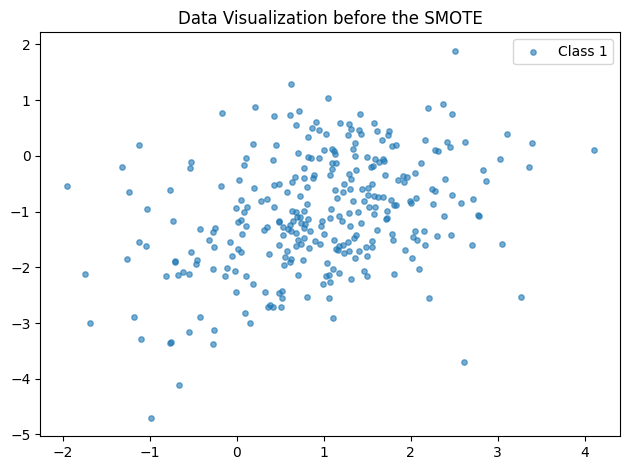

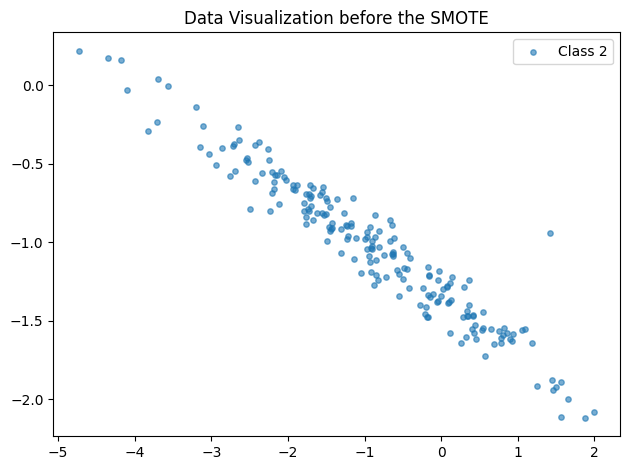

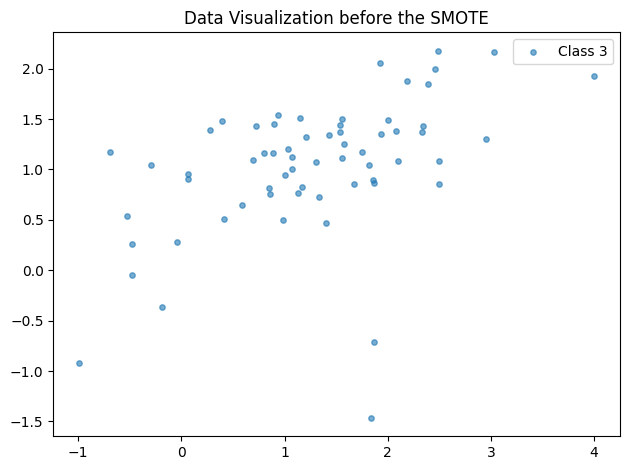

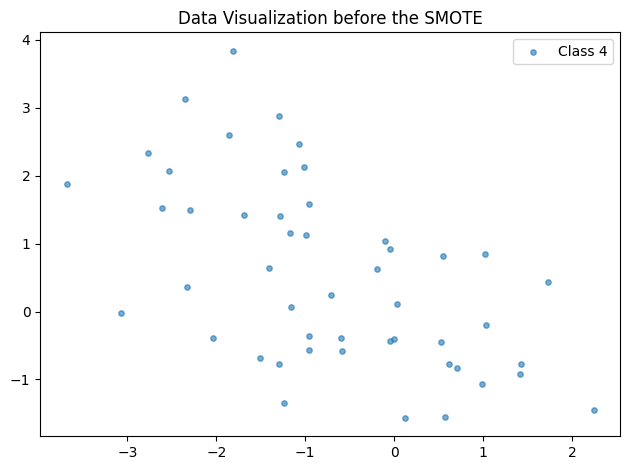

In [24]:
#plotting scatter plot of Data points
plt.subplot(1,2,2)
for i in range (5):
    plt.scatter(X[y == i, 0], X[y == i, 1], label =f'Class {i}', alpha =0.6, s= 15)
    plt.title('Data Visualization before the SMOTE')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [25]:
# Applying SMOTE
#in this case, we try balance the minority class to match the majority class (Class 0)
smote = SMOTE(random_state = 42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print  (f'Resampled dataset shape: {Counter(y_resampled)}')

Resampled dataset shape: Counter({np.int64(0): 1392, np.int64(1): 1392, np.int64(2): 1392, np.int64(3): 1392, np.int64(4): 1392})


Text(0, 0.5, 'Number of Samples')

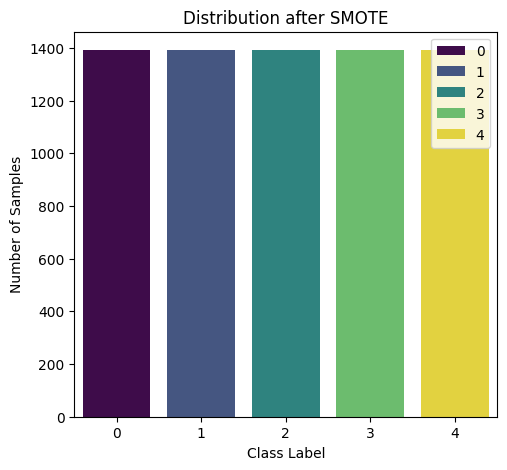

In [29]:
# Visualisation after SMOTE using a Bar Chart, Now we have a balanced class count
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x=y_resampled, hue= y_resampled, palette='viridis')
plt.title('Distribution after SMOTE')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')


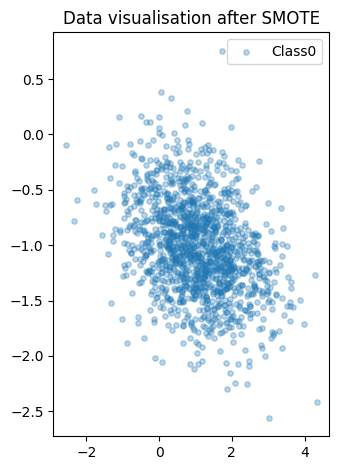

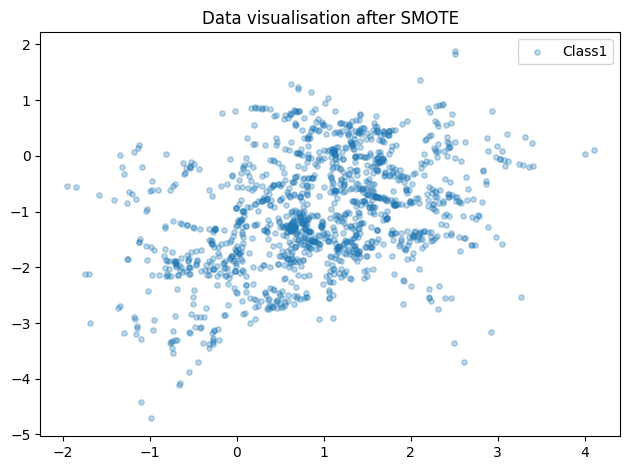

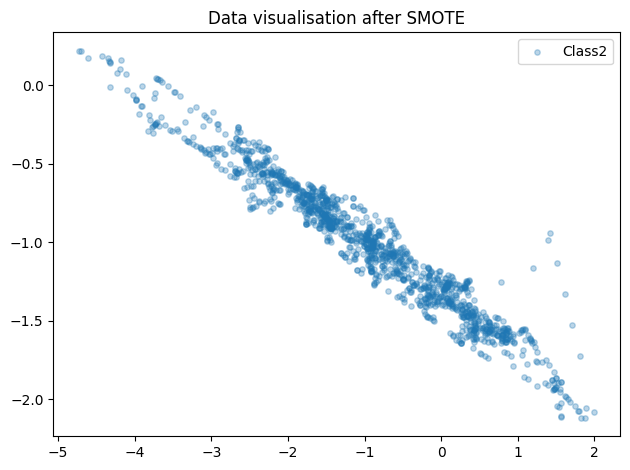

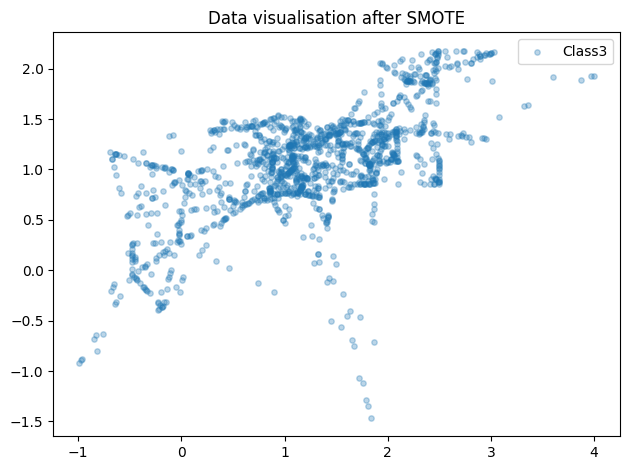

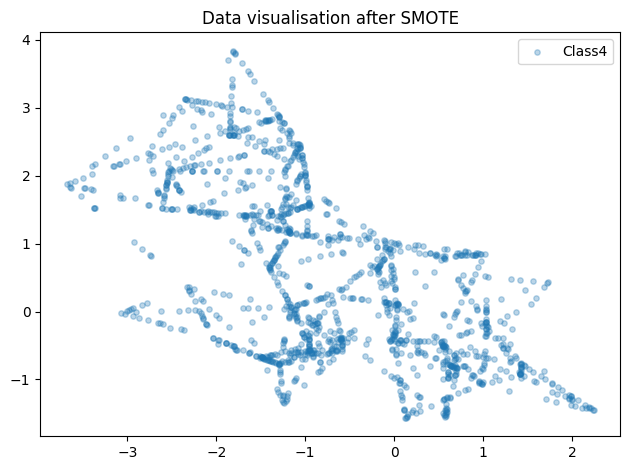

In [30]:
# now we can view the scatter plot of hte Resampled Data
plt.subplot(1, 2, 2)
for i in range (5):
    plt.scatter(X_resampled[y_resampled== i, 0], X_resampled[y_resampled == i, 1],
                label = f'Class{i}', alpha =0.3, s=15)
    plt.title('Data visualisation after SMOTE')
    plt.legend()

    plt.tight_layout()
    plt.show()